In [1]:
from torch.utils.data import DataLoader
from data_loader import GripperDataset, plot_images, compute_mean_images, load_images
import cv2
import numpy as np
import os

Create dataset and load data

In [2]:
experiment = "data_collection_clean_env"
sessions = ["1","2"]
path = "D:\\Jack\\KTH\\Research project in Robotics\\cloudgripper-visual-autoencoder\\autograsper\\recorded_data\\data_collection_clean_env"
# dataset = GripperDataset(experiment=experiment, sessions=sessions)
dataset = GripperDataset(abs_path=path, sessions=sessions)

dataloader = DataLoader(dataset, batch_size=10, shuffle=True)

Loading data session 1
Loading data session 2


Number of samples in the dataset:  4767
Number of batches in the dataloader:  477
Shape bottom image:  [3, 640, 480]
Shape top image:  [3, 720, 1280]
Shape state array:  [5]


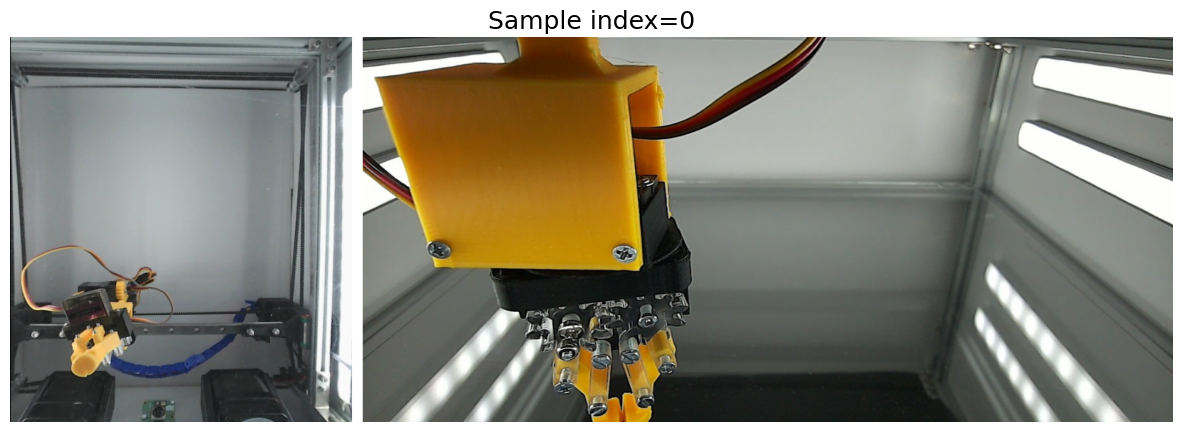

In [3]:
print("Number of samples in the dataset: ", dataset.__len__())
print("Number of batches in the dataloader: ", len(dataloader))
index = 0
bottom_img, top_img, state = dataset[index]

print("Shape bottom image: ", [*bottom_img.shape])
print("Shape top image: ", [*top_img.shape])
print("Shape state array: ", [*state.shape])

plot_images(bottom_img, top_img, title=f"Sample index={index}")

### Mean image
The average of a lot of images is an image of the clean environment, since that is the only static thing while the robot moves. However such average might be biased.

Loading existing mean images
Shape mean bottom image:  [3, 640, 480]
Shape mean top image:  [3, 720, 1280]


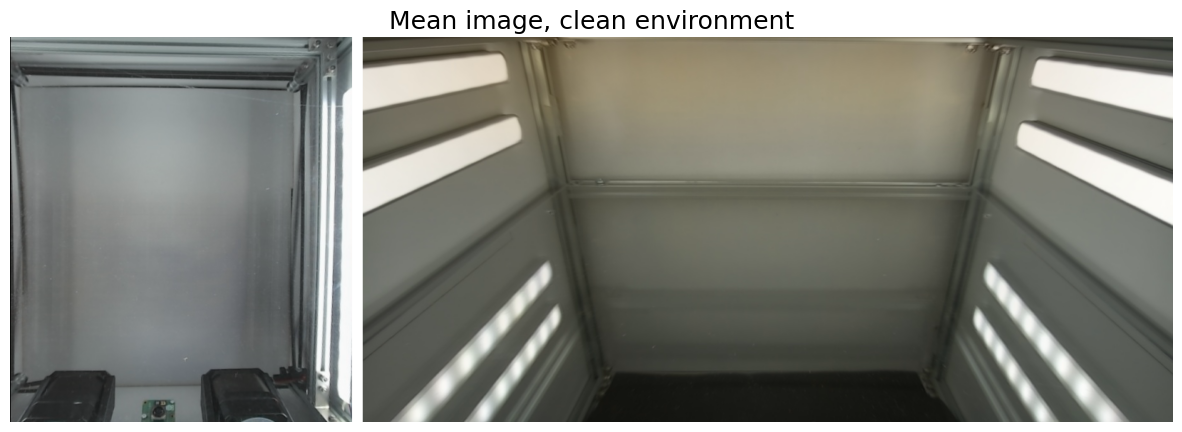

In [4]:
name = "_mean_Experiment_" + experiment + "_Sessions_" + "_".join(sessions)
path = "clean_environment_images"
mean_bottom_file = os.path.join(path, f"bottom{name}.jpeg")
mean_top_file = os.path.join(path, f"top{name}.jpeg")

# import mean image, clean environment, if it exists
if os.path.exists(mean_bottom_file) and os.path.exists(mean_top_file):
    print("Loading existing mean images")
    mean_bottom, mean_top = load_images(path, name)

else:
    print("Calculating mean images")
    mean_bottom, mean_top = compute_mean_images(dataloader, path=path, name=name)

print("Shape mean bottom image: ", [*mean_bottom.shape])
print("Shape mean top image: ", [*mean_top.shape])
plot_images(mean_bottom, mean_top, title="Mean image, clean environment")

In [ ]:
def to_uint8(img):
    if img.dtype == np.uint8:
        return img
    img *= 255
    return np.astype(img, np.uint8)

def to_float32(img):
    if img.dtype == np.float32:
        return img
    img = np.astype(img, np.float32)
    return img/255

Remove background, robot mask extraction, by subtracting the clean environment image. 

Then apply threshold to get the mask.

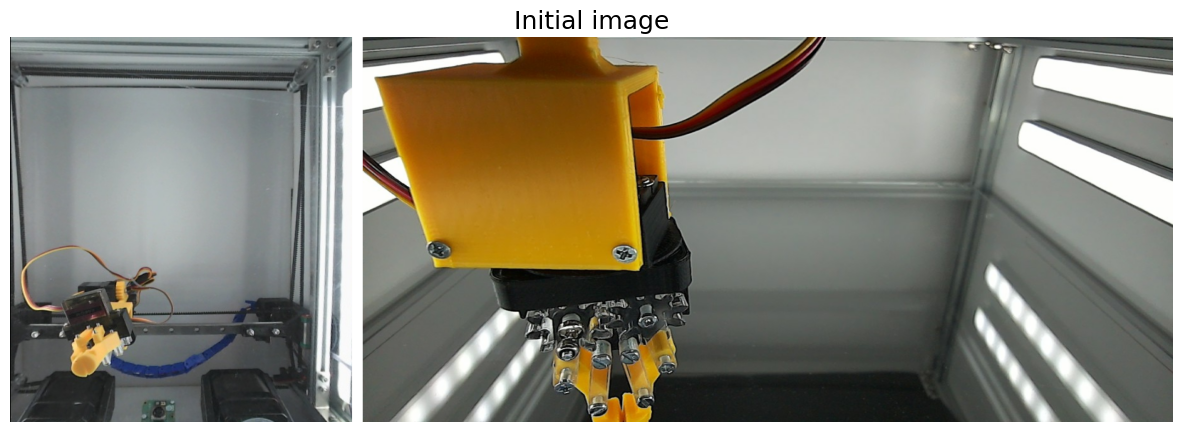

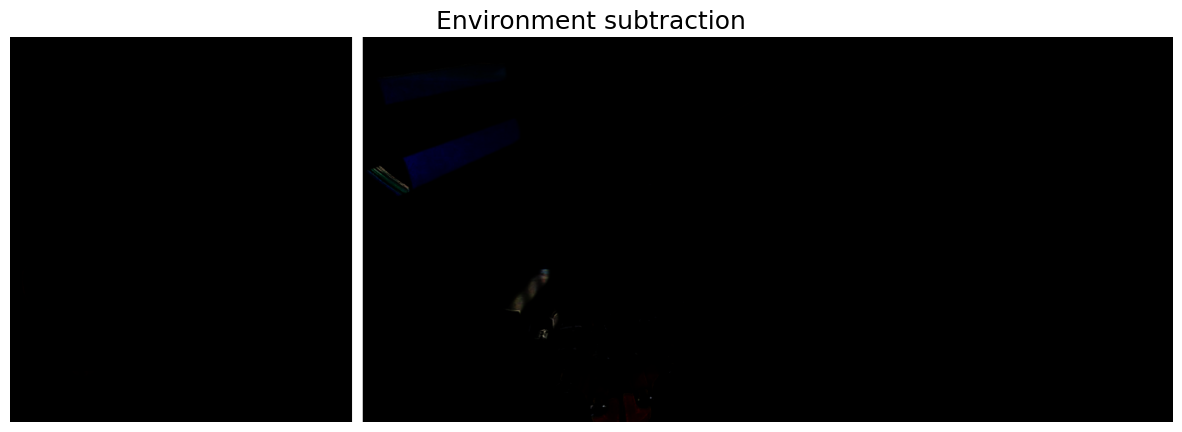

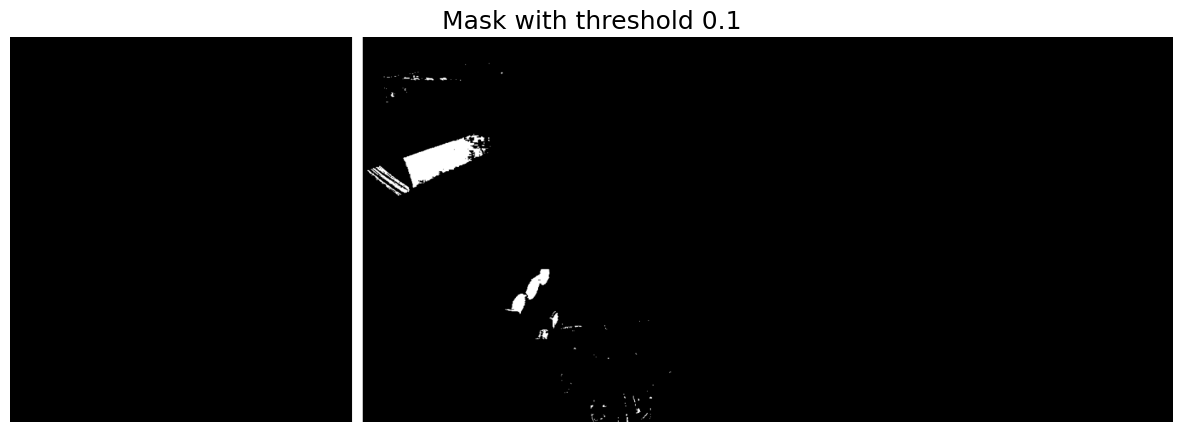

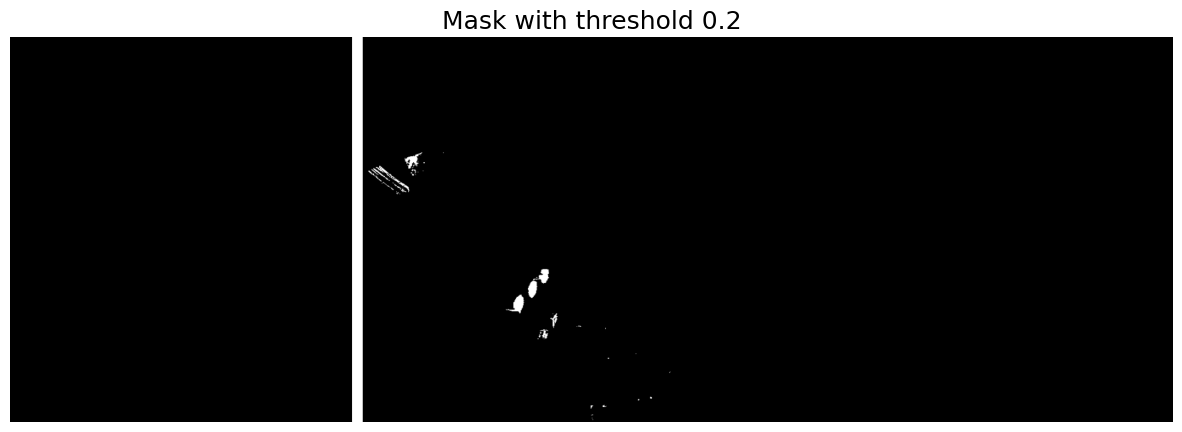

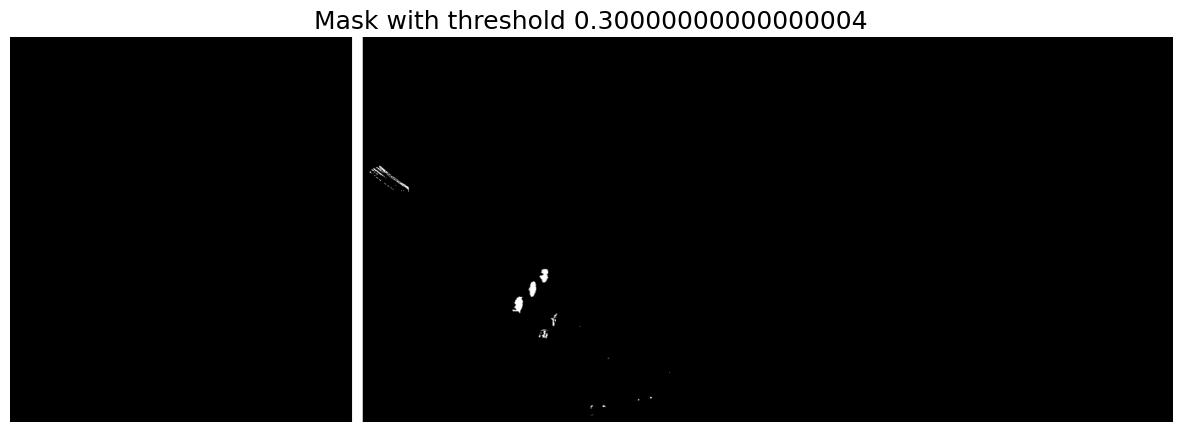

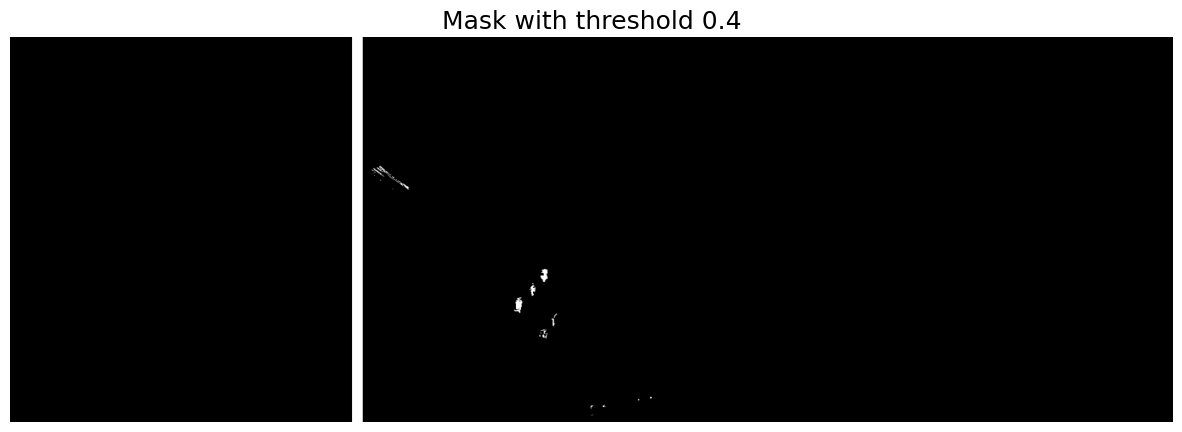

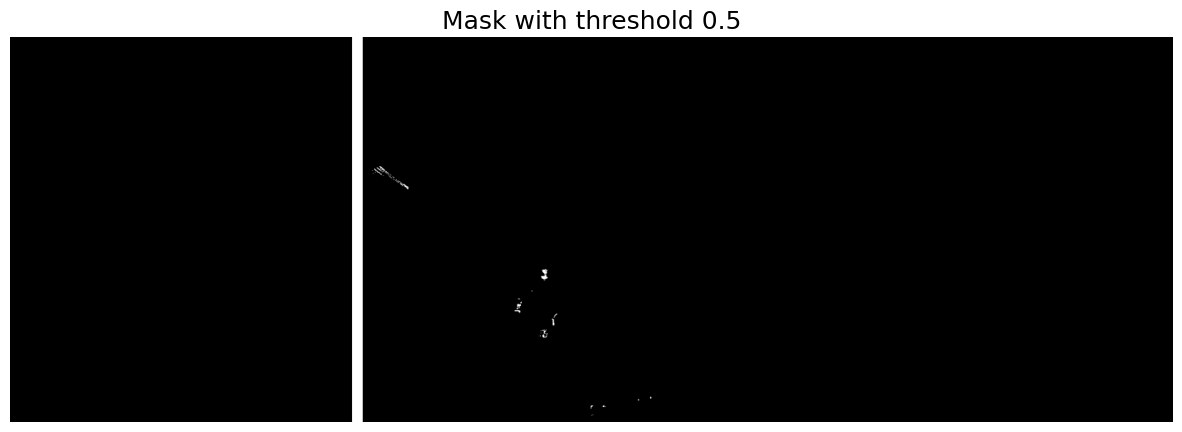

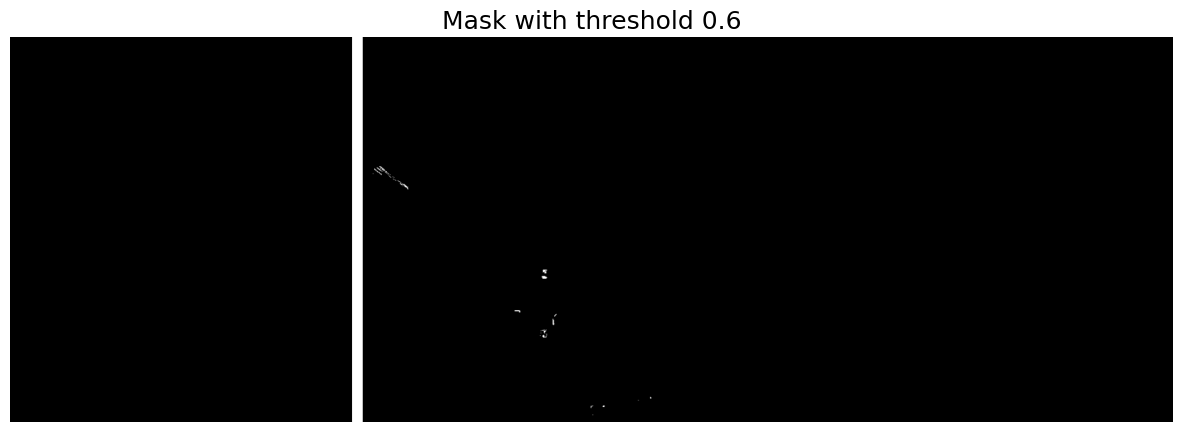

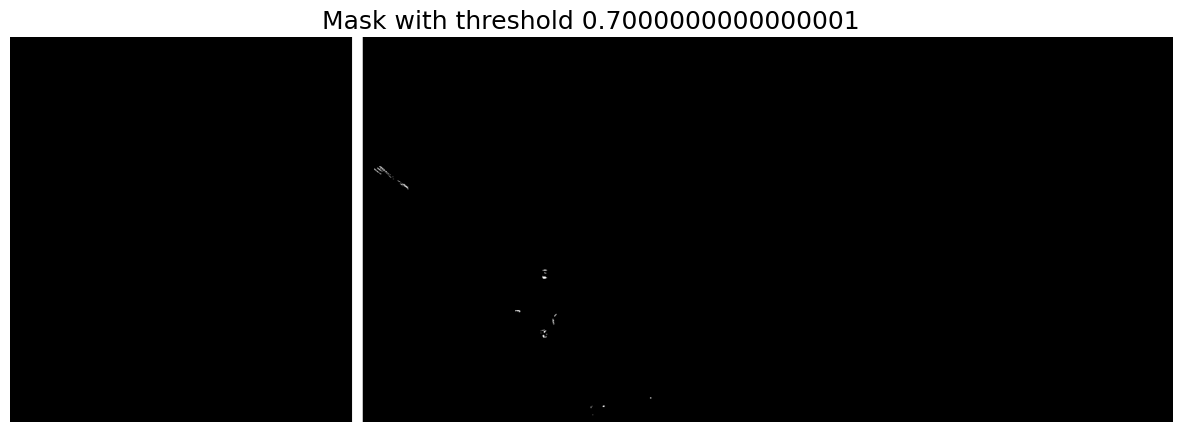

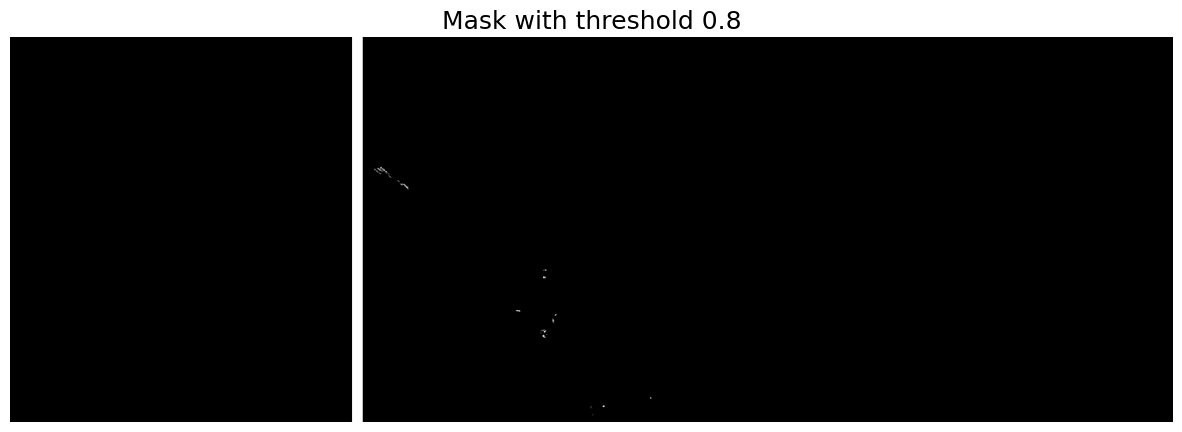

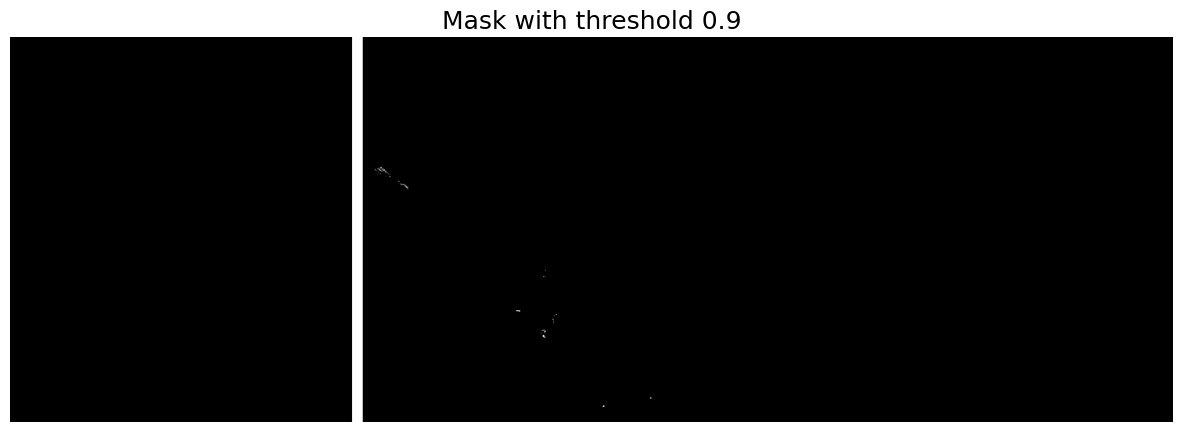

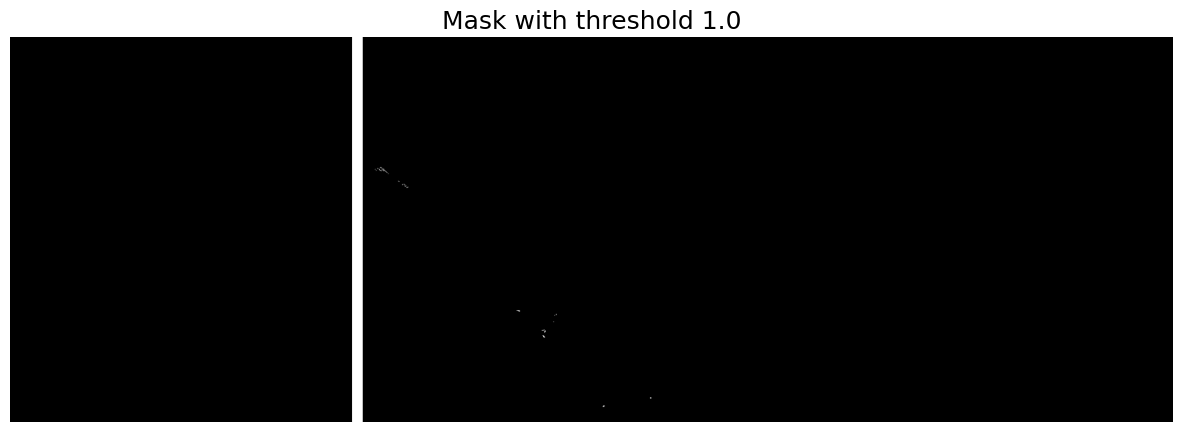

In [ ]:
# threshold the sum of the 3 RGB values
thresholds = np.linspace(0.1,1,10)

for i in range(1):
    bottom_img, top_img, state = dataset[i]
    bottom_img = bottom_img.numpy()
    top_img = top_img.numpy()
    plot_images(bottom_img, top_img, title="Initial image")

    mask_bottom = np.abs(mean_bottom - bottom_img)
    mask_top = np.abs(mean_top - top_img)
    # mask_bottom = np.sqrt((mean_bottom - bottom_img)**2)
    # mask_top = np.sqrt((mean_top - top_img)**2)
    plot_images(mask_bottom, mask_top, title="Environment subtraction")

    # sum RGB values
    rgb_bottom = mask_bottom.sum(axis=0)[np.newaxis,:,:]
    rgb_top = mask_top.sum(axis=0)[np.newaxis,:,:]

    for threshold in thresholds:
        mask_bottom = np.where(np.repeat(rgb_bottom,3,axis=0)<threshold, 0, 1).astype(np.float32)
        mask_top = np.where(np.repeat(rgb_top,3,axis=0)<threshold, 0, 1).astype(np.float32)
        plot_images(mask_bottom, mask_top, title=f"Mask with threshold {threshold}")


1. Euclidian distasnce between RGB pixels
2. Add gaussian noise
3. Threshold the sum of the 3 RGB values
4. Morphological operation: Close

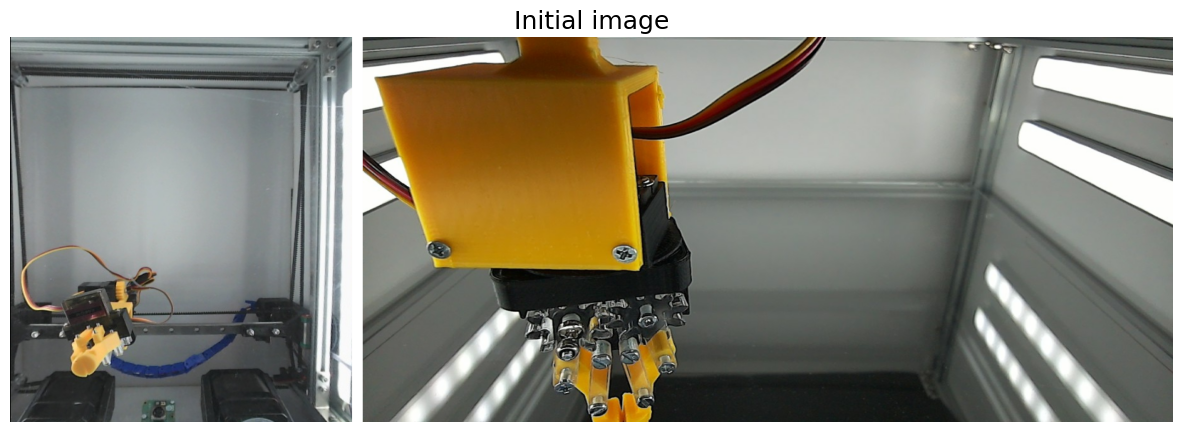

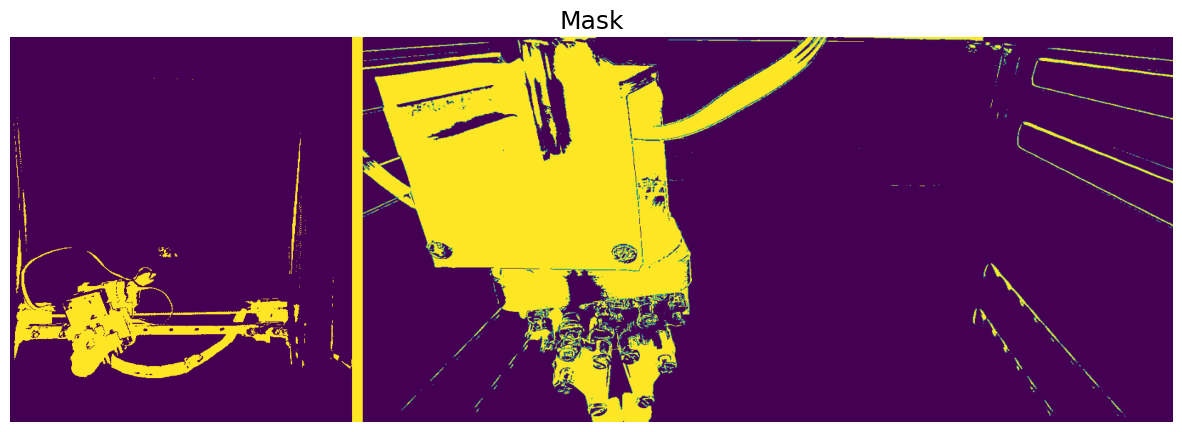

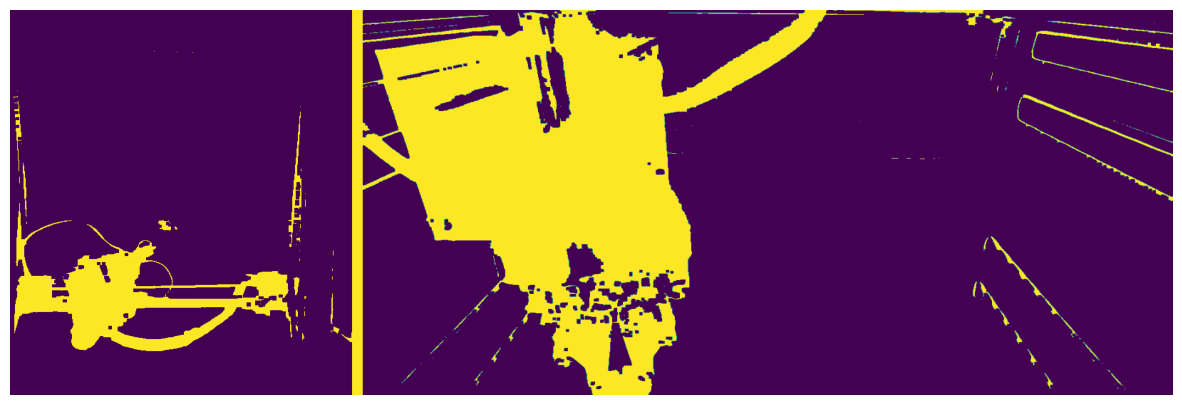

In [44]:
# threshold the sum of the 3 RGB values
thresholds = np.linspace(0.1,1,10)

for i in range(1):
    bottom_img, top_img, state = dataset[i]
    bottom_img = bottom_img.numpy()
    top_img = top_img.numpy()
    plot_images(bottom_img, top_img, title="Initial image")

    # euclidian distance between RGB pixels
    bottom_distance = np.linalg.norm(bottom_img - mean_bottom, axis=0)
    bottom_distance /= bottom_distance.max()
    top_distance = np.linalg.norm(top_img - mean_top, axis=0)
    top_distance /= top_distance.max()
    
    # mask_top = cv2.adaptiveThreshold(to_uint8(top_distance),255,cv2.ADAPTIVE_THRESH_MEAN_C,\
    #     cv2.THRESH_BINARY,159,5)
    # mask_top = to_float32(mask_top)
    mask_bottom = cv2.threshold(bottom_distance, 0.3, 1, cv2.THRESH_BINARY)[1]
    mask_top = cv2.threshold(top_distance, 0.2, 1, cv2.THRESH_BINARY)[1]
    plot_images(mask_bottom, mask_top, title="Mask")

    kernel = np.ones((5, 5), np.uint8)
    mask_bottom = cv2.morphologyEx(to_uint8(mask_bottom), cv2.MORPH_CLOSE, kernel, iterations=1)
    mask_bottom = to_float32(mask_bottom)
    mask_top = cv2.morphologyEx(to_uint8(mask_top), cv2.MORPH_CLOSE, kernel, iterations=1)
    mask_top = to_float32(mask_top)
    plot_images(mask_bottom, mask_top)


1. Euclidian distasnce between RGB pixels
2. Add gaussian noise
3. Threshold the sum of the 3 RGB values
4. Morphological operation: Open + Close


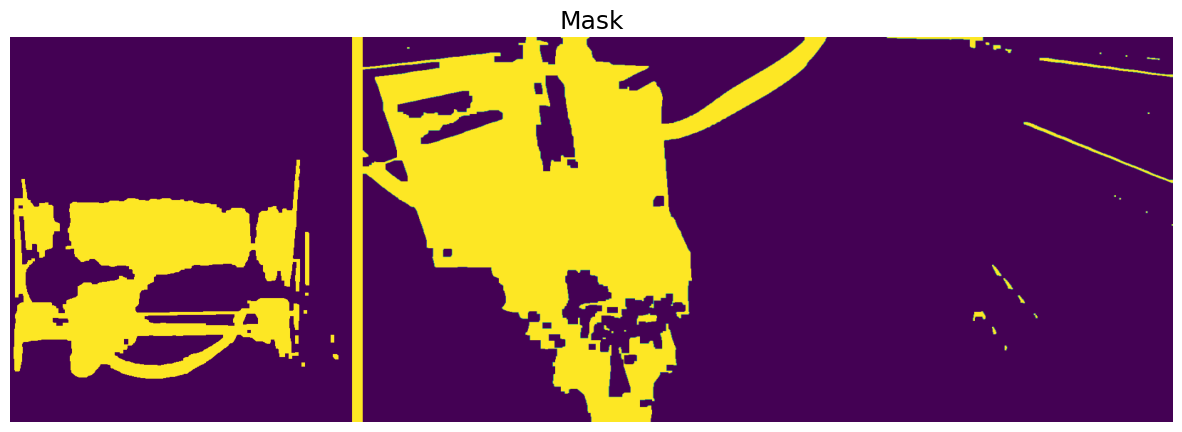

In [ ]:
# Assuming bottom_img and top_img are float32 in [0, 1] range
bottom_img, top_img, state = dataset[i]
bottom_img = bottom_img.numpy()
top_img = top_img.numpy()

# Compute Euclidean distance
bottom_distance = np.linalg.norm(bottom_img - mean_bottom, axis=0)
bottom_distance /= bottom_distance.max()  # Normalize to [0, 1]
top_distance = np.linalg.norm(top_img - mean_top, axis=0)
top_distance /= top_distance.max()  # Normalize to [0, 1]

# Convert to uint8 for OpenCV (scale up to [0, 255])
blurred_bottom = (cv2.GaussianBlur(bottom_distance, (5, 5), 0) * 255).astype(np.uint8)
blurred_top = (cv2.GaussianBlur(top_distance, (5, 5), 0) * 255).astype(np.uint8)

# Apply Otsu's thresholding
_, mask_bottom = cv2.threshold(blurred_bottom, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
_, mask_top = cv2.threshold(blurred_top, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Morphological operations for noise removal
kernel = np.ones((3, 3), np.uint8)
mask_bottom_cleaned = cv2.morphologyEx(mask_bottom, cv2.MORPH_OPEN, kernel, iterations=2)
mask_bottom_cleaned = cv2.morphologyEx(mask_bottom_cleaned, cv2.MORPH_CLOSE, kernel, iterations=2)
mask_top_cleaned = cv2.morphologyEx(mask_top, cv2.MORPH_OPEN, kernel)
mask_top_cleaned = cv2.morphologyEx(mask_top_cleaned, cv2.MORPH_CLOSE, kernel, iterations=5)

# Convert back to float32 in [0, 1] range
mask_bottom_cleaned = mask_bottom_cleaned.astype(np.float32) / 255.0
mask_top_cleaned = mask_top_cleaned.astype(np.float32) / 255.0

plot_images(mask_bottom_cleaned, mask_top_cleaned, title="Mask")

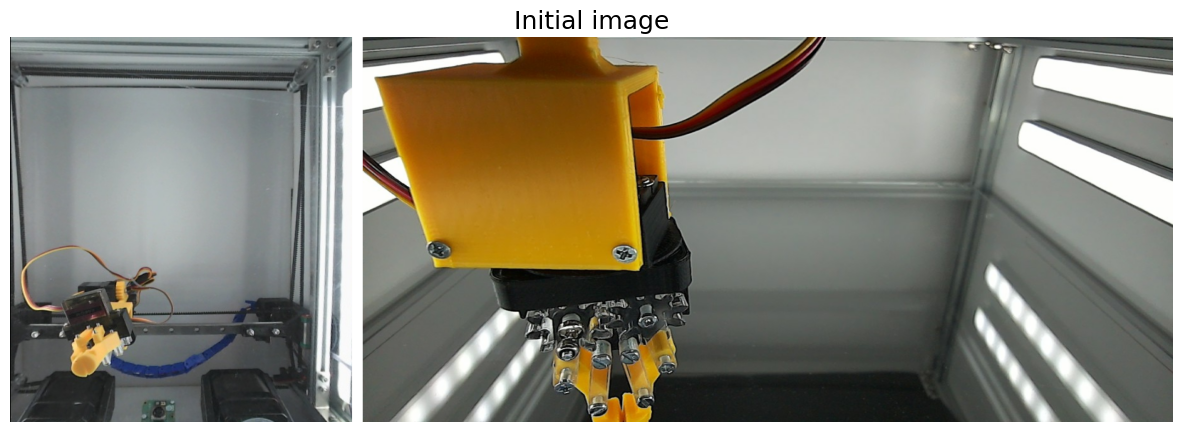

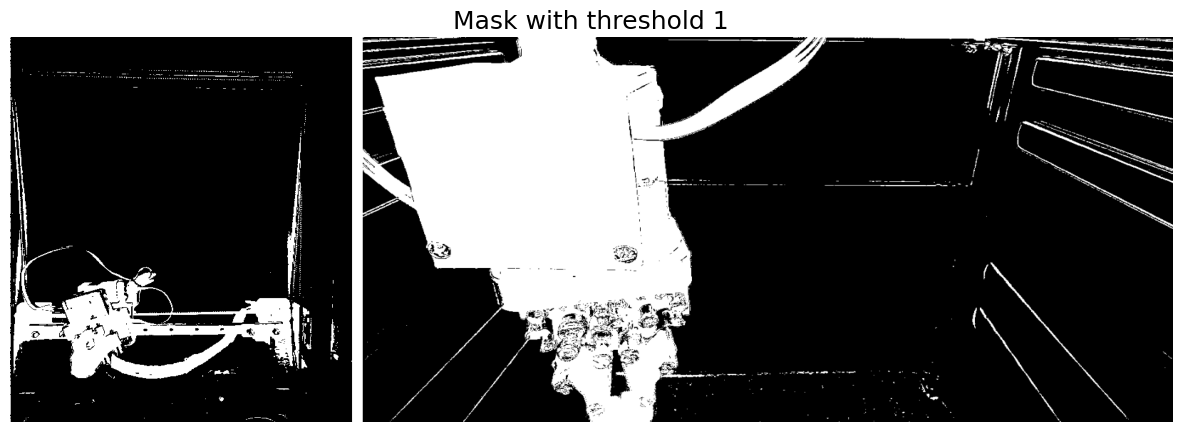

In [ ]:
# threshold the sum of the 3 RGB values
thresholds = [1] #np.linspace(0.1,2,10)

bottom_img, top_img, state = dataset[0]
bottom_img = bottom_img.numpy()
top_img = top_img.numpy()
plot_images(bottom_img, top_img, title="Initial image")

epsilon = 1e-8
mask_bottom = np.abs(np.log(mean_bottom +epsilon) - np.log(bottom_img +epsilon))
mask_top = np.abs(np.log(mean_top +epsilon) - np.log(top_img +epsilon))
# plot_images(mask_bottom, mask_top, title="Environment subtraction")

# sum RGB values
rgb_bottom = mask_bottom.sum(axis=0)[np.newaxis,:,:]
rgb_top = mask_top.sum(axis=0)[np.newaxis,:,:]

for threshold in thresholds:
    mask_bottom = np.where(np.repeat(rgb_bottom,3,axis=0)<threshold, 0, 1).astype(np.float32)
    mask_top = np.where(np.repeat(rgb_top,3,axis=0)<threshold, 0, 1).astype(np.float32)
    plot_images(mask_bottom, mask_top, title=f"Mask with threshold {threshold}")


In [ ]:
mask = to_uint8(mask_bottom[0]).squeeze()
cv2.connectedComponentsWithStats(mask, 4, cv2.CV_32S)

(523,
 array([[  1,   0,   0, ...,   0,   0,   0],
        [  1,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [517,   0,   0, ...,   0,   0,   0],
        [517,   0,   0, ...,   0,   0,   0],
        [517,   0,   0, ...,   0,   0,   0]], shape=(640, 480), dtype=int32),
 array([[     0,      0,    480,    640, 273358],
        [     0,      0,      1,      2,      2],
        [     0,      3,      1,      2,      2],
        ...,
        [    22,    636,      1,      1,      1],
        [   368,    637,      1,      1,      1],
        [   371,    639,      1,      1,      1]],
       shape=(523, 5), dtype=int32),
 array([[2.45367342e+02, 3.02441805e+02],
        [0.00000000e+00, 5.00000000e-01],
        [0.00000000e+00, 3.50000000e+00],
        ...,
        [2.20000000e+01, 6.36000000e+02],
        [3.68000000e+02, 6.37000000e+02],
        [3.71000000e+02, 6.39000000e+02]], shape=(523, 2)))

Robot extraction from mask

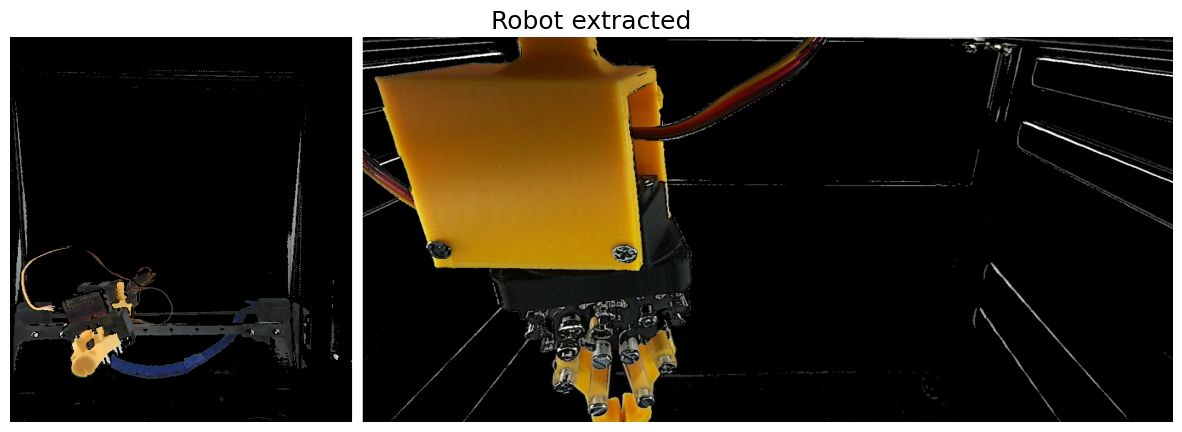

In [69]:
robot_bottom = np.where(mask_bottom, bottom_img, 0).astype(np.float32)
robot_top = np.where(mask_top, top_img, 0).astype(np.float32)
plot_images(robot_bottom, robot_top, title="Robot extracted")